In [1]:
import os
from pathlib import Path
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

# new
from torch.amp import autocast, GradScaler

import matplotlib.pyplot as plt

In [2]:
# ---- paths ----
DATA_ROOT = Path("/cluster/courses/cil/monocular-depth-estimation/train")

# ---- training config ----
IMG_SIZE = 128          # 128 is nice for a live demo
BATCH_SIZE = 8
NUM_EPOCHS = 120
LR = 1e-3
MAX_TRAIN_SAMPLES = 3000   # keep small for speed in live demo
MAX_VAL_SAMPLES = 500
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# new
SAVE_PATH = os.getcwd()
start_epoch = 0
print(SAVE_PATH)

print("Using device:", DEVICE)

/home/ribadov
Using device: cuda


In [3]:
class SimpleDepthDataset(Dataset):
    def __init__(self, root: Path, img_size=128, max_samples=None):
        self.root = Path(root)
        self.img_size = img_size
        
        self.rgb_files = sorted(self.root.glob("*_rgb.png"))
        if max_samples is not None:
            self.rgb_files = self.rgb_files[:max_samples]
        
        assert len(self.rgb_files) > 0, f"No *_rgb.png files found in {self.root}"

    def __len__(self):
        return len(self.rgb_files)

    def __getitem__(self, idx):
        rgb_path = self.rgb_files[idx]
        depth_path = Path(str(rgb_path).replace("_rgb.png", "_depth.npy"))
        
        # load rgb
        rgb = np.array(Image.open(rgb_path).convert("RGB"), dtype=np.float32) / 255.0
        
        # load depth
        depth = np.load(depth_path).astype(np.float32)
        
        # resize rgb
        rgb_t = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0)   # [1,3,H,W]
        rgb_t = F.interpolate(rgb_t, size=(self.img_size, self.img_size), mode="bilinear", align_corners=False)
        rgb_t = rgb_t.squeeze(0)  # [3,H,W]
        
        # resize depth
        depth_t = torch.from_numpy(depth).unsqueeze(0).unsqueeze(0)   # [1,1,H,W]
        depth_t = F.interpolate(depth_t, size=(self.img_size, self.img_size), mode="nearest")
        depth_t = depth_t.squeeze(0)  # [1,H,W]
        
        # valid mask: depth > 0
        valid_mask = (depth_t > 0).float()
        
        # optional normalization of valid depth values
        # keeps the target range smaller and easier for the toy model
        depth_t = torch.clamp(depth_t, min=0.0, max=80.0)
        depth_t = depth_t / 80.0
        
        return {
            "image": rgb_t,
            "depth": depth_t,
            "mask": valid_mask,
            "name": rgb_path.name
        }

In [4]:
full_dataset = SimpleDepthDataset(DATA_ROOT, img_size=IMG_SIZE, max_samples=MAX_TRAIN_SAMPLES + MAX_VAL_SAMPLES)

n_total = len(full_dataset)
n_val = min(MAX_VAL_SAMPLES, max(1, int(0.15 * n_total)))
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

Train samples: 3000
Val samples:   500


In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.enc1 = DoubleConv(3, 16)
        self.pool1 = nn.MaxPool2d(2)
        
        self.enc2 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool2d(2)
        
        self.bottleneck = DoubleConv(32, 64)
        
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(64, 32)
        
        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(32, 16)
        
        self.out_conv = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)          # [B,16,H,W]
        e2 = self.enc2(self.pool1(e1))   # [B,32,H/2,W/2]
        
        b = self.bottleneck(self.pool2(e2))  # [B,64,H/4,W/4]
        
        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        
        out = self.out_conv(d1)
        out = torch.sigmoid(out)   # output in [0,1]
        return out


model = TinyUNet().to(DEVICE)
print(model)
# new
SAVE_PATH += "/" + str(model.__class__.__name__) + ".pth"
print(SAVE_PATH)
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

TinyUNet(
  (enc1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (net): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (up2

In [6]:
def silog_loss(pred, target, mask, lambda_=0.5, eps=1e-6):
    """
    Scale-Invariant Log RMSE (SILog)

    pred, target: [B,1,H,W]
    mask:         [B,1,H,W] (1 = valid, 0 = ignore)
    """
    # keep only valid pixels
    pred = pred[mask > 0]
    target = target[mask > 0]
    
    # avoid log(0)
    pred = torch.clamp(pred, min=eps)
    target = torch.clamp(target, min=eps)
    
    log_diff = torch.log(pred) - torch.log(target)
    
    mse = torch.mean(log_diff ** 2)
    mean = torch.mean(log_diff)
    
    loss = mse - lambda_ * (mean ** 2)
    return loss

In [7]:
# new
def compute_depth_metrics(pred, target, mask, eps=1e-6):
    valid = mask > 0
    if valid.sum() == 0:
        return {"abs_rel": float("nan"), "rmse": float("nan")}

    p = pred[valid]
    t = target[valid]

    abs_rel = torch.mean(torch.abs(p - t) / torch.clamp(t, min=eps))
    rmse = torch.sqrt(torch.mean((p - t) ** 2))
    return {"abs_rel": abs_rel.item(), "rmse": rmse.item()}

In [8]:
# new
def compute_scale_invariant_rmse(pred, target, mask, lambda_=1.0, eps=1e-6):
    valid = mask > 0
    if valid.sum() == 0:
        return float('nan')
    p = pred[valid]
    t = target[valid]
    log_diff = torch.log(p + eps) - torch.log(t + eps)
    mse = torch.mean(log_diff ** 2)
    mean_err = torch.mean(log_diff)
    return torch.sqrt(mse - lambda_ * (mean_err ** 2)).item()

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
# new
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    
    total_loss = 0.0
    
    total_abs_rel = 0.0
    total_rmse = 0.0
    total_si_rmse = 0.0
    n_batches = 0
    # Only use AMP scaler on CUDA; disable autocast for loss stability
    use_amp = is_train and DEVICE == "cuda"
    scaler = GradScaler('cuda') if use_amp else None
    
    for batch in loader:
        images = batch["image"].to(DEVICE)
        depths = batch["depth"].to(DEVICE)
        masks = batch["mask"].to(DEVICE)
        
        with torch.set_grad_enabled(is_train):
            preds = model(images)
            loss = silog_loss(preds, depths, masks)
            
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        # new
        with torch.no_grad():
            metrics = compute_depth_metrics(preds.detach(), depths, masks)
            si_rmse = compute_scale_invariant_rmse(preds.detach(), depths, masks)
            
        total_loss += loss.item()
        total_abs_rel += metrics["abs_rel"] if not np.isnan(metrics["abs_rel"]) else 0.0
        total_rmse    += metrics["rmse"]    if not np.isnan(metrics["rmse"])    else 0.0
        total_si_rmse += si_rmse            if not np.isnan(si_rmse)            else 0.0
        n_batches += 1

    n = max(1, n_batches)
    return {
        "loss":    total_loss    / n,
        "abs_rel": total_abs_rel / n,
        "rmse":    total_rmse    / n,
        "si_rmse": total_si_rmse / n,
    }
    # old
    #return total_loss / len(loader)

# old
#for epoch in range(NUM_EPOCHS):
#    train_loss = run_epoch(train_loader, model, optimizer=optimizer)
#    val_loss = run_epoch(val_loader, model, optimizer=None)
#    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}")

# new
if Path(SAVE_PATH).exists():
    checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
    model = TinyUNet().to(DEVICE) # modification
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=38, eta_min=1e-5)  
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print("Loaded pre-trained weights.")
else:
    print("No saved weights found, starting from scratch.")


for epoch in range(start_epoch, NUM_EPOCHS):
    train_loss = run_epoch(train_loader, model, optimizer=optimizer)
    val_loss = run_epoch(val_loader, model, optimizer=None)
    scheduler.step(val_loss['si_rmse'])
    # scheduler.step()
    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train loss: {train_loss['loss']:.4f}, AbsRel: {train_loss['abs_rel']:.4f}, RMSE: {train_loss['rmse']:.4f}, si_rmse: {train_loss['si_rmse']:.4f} | "
        f"val loss: {val_loss['loss']:.4f}, AbsRel: {val_loss['abs_rel']:.4f}, RMSE: {val_loss['rmse']:.4f}, si_rmse: {val_loss['si_rmse']:.4f} "
    )
    checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    #'model_config': {'features': model.features},
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': val_loss['loss']
    # 'scheduler_state_dict': scheduler.state_dict()
    }
    torch.save(checkpoint, SAVE_PATH)

Loaded pre-trained weights.
Epoch 120/120 | train loss: 0.7770, AbsRel: 5.0526, RMSE: 0.1153, si_rmse: 0.8524 | val loss: 0.9418, AbsRel: 5.6705, RMSE: 0.1344, si_rmse: 0.9348 


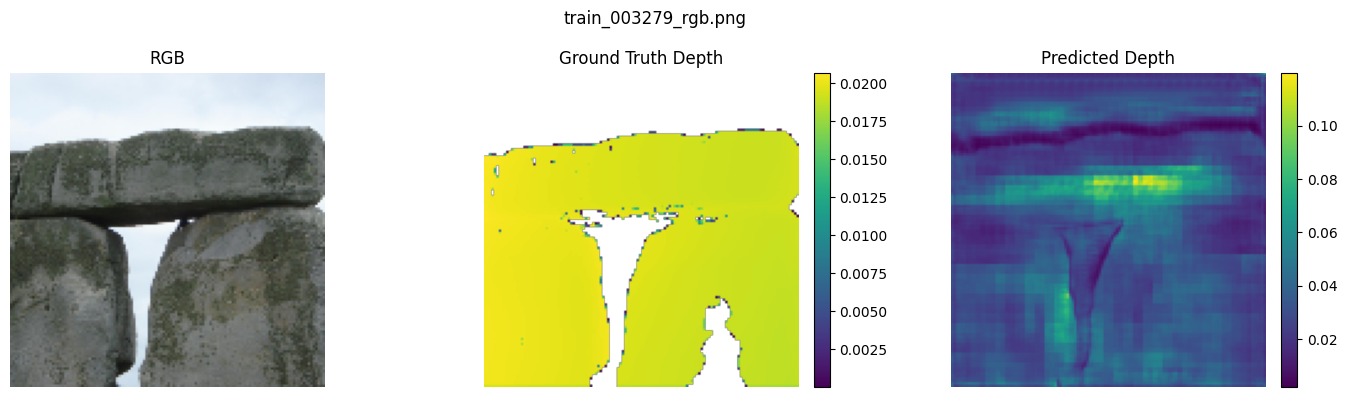

In [10]:
model.eval()

batch = next(iter(val_loader))
images = batch["image"].to(DEVICE)
depths = batch["depth"].to(DEVICE)
masks = batch["mask"].to(DEVICE)
names = batch["name"]

with torch.no_grad():
    preds = model(images)

i = 0
img = images[i].cpu().permute(1, 2, 0).numpy()
gt = depths[i, 0].cpu().numpy()
pred = preds[i, 0].cpu().numpy()
mask = masks[i, 0].cpu().numpy()

# hide invalid gt pixels
gt_vis = gt.copy()
gt_vis[mask == 0] = np.nan

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_vis, cmap="viridis")
plt.title("Ground Truth Depth")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="viridis")
plt.title("Predicted Depth")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.suptitle(names[i])
plt.tight_layout()
plt.show()

In [11]:
print(torch.cuda.get_device_name(0))
print(f"GPU cap:  {torch.cuda.get_device_capability(0)}")

print("Val batches:", len(val_loader))
print("Val samples:", len(val_dataset))

NVIDIA GeForce RTX 5060 Ti
GPU cap:  (12, 0)
Val batches: 63
Val samples: 500


In [12]:
TEST_ROOT  = Path("/cluster/courses/cil/monocular-depth-estimation/test")
PRED_DIR   = Path("./predictions")
PRED_DIR.mkdir(exist_ok=True)

IMG_SIZE = 320

model.eval()

test_rgb_files = sorted(TEST_ROOT.glob("test_*_rgb.png"))  
print(f"Found {len(test_rgb_files)} test images")

with torch.no_grad():
    for img_path in test_rgb_files:
        rgb = np.array(Image.open(img_path).convert("RGB"), dtype=np.float32) / 255.0
        rgb_t = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0)
        rgb_t = F.interpolate(rgb_t, size=(IMG_SIZE, IMG_SIZE),
                              mode="bilinear", align_corners=False).to(DEVICE)

        pred = model(rgb_t)
        pred = pred.squeeze().cpu().numpy()
        pred = pred * 80.0  

        idx = img_path.stem.split("_")[-2]   
        out_path = PRED_DIR / f"test_{idx}.npy"
        np.save(out_path, pred.astype(np.float32))

print(f"Saved {len(test_rgb_files)} predictions to {PRED_DIR}")

Found 591 test images
Saved 591 predictions to predictions


In [13]:
import base64, zlib, pandas as pd

def encode_depth(depth: np.ndarray) -> str:
    depth = np.asarray(depth, dtype=np.float16)
    compressed = zlib.compress(depth.tobytes(), level=9)
    return base64.b64encode(compressed).decode("utf-8")

pred_dir = Path("./predictions")   # same as PRED_DIR above
out_csv  = Path("./submission.csv")

rows = []
for pred_path in sorted(pred_dir.glob("test_*.npy")):
    depth = np.load(pred_path)
    idx   = pred_path.stem.split("_")[-1]
    rows.append({"id": f"test_{idx}_depth", "Depths": encode_depth(depth)})

df = pd.DataFrame(rows, columns=["id", "Depths"])
df.to_csv(out_csv, index=False)
print(f"Saved {len(df)} predictions → {out_csv}")

Saved 591 predictions → submission.csv
